# 03 — HMM Regime Detection

This notebook covers **Phase 2a** of the HMM-LSTM volatility forecasting project:

**2a. Simple Gaussian vs Gaussian Mixture**

- Train `GaussianHMM(n_components=2)` — equivalent to `GMMHMM(n_mix=1)`
- Train `GMMHMM(n_components=2, n_mix=2)` and `GMMHMM(n_components=2, n_mix=3)`
- Compare via validation-set log-likelihood, BIC, and AIC
- Save the winning model to `models/`

**HMM features** (defined in `config.py` — always the authoritative source):

```
HMM_FEATURES = [
    'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume',
    'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10',
    'rolling_mean_21', 'rolling_std_21',
]
```

These 11 features were selected after correlation pruning in notebook 01 (threshold=0.95,
dropped `rolling_abs_mean_5/10/21` as highly correlated with `rolling_std_*` counterparts).
VIF is informational only — no features are dropped on VIF grounds.

> **Phases 2b (higher-order Markov) and 2c (Viterbi sanity check) are covered in later sessions.**


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print("Setup complete.")

Setup complete.


In [2]:
from config import (
    DATA_PROCESSED,
    MODELS_DIR,
    HMM_FEATURES,
    HMM_N_STATES,
    HMM_N_MIX,
    HMM_COVARIANCE_TYPE,
    HMM_N_ITER,
    HMM_RANDOM_STATE,
    HMM_N_RESTARTS,
    HMM_DURATION_PENALTY,
)

print("HMM_FEATURES        :", HMM_FEATURES)
print("HMM_N_STATES        :", HMM_N_STATES)
print("HMM_N_MIX           :", HMM_N_MIX)
print("covariance_type     :", HMM_COVARIANCE_TYPE)
print("n_iter              :", HMM_N_ITER)
print("random_state        :", HMM_RANDOM_STATE)
print("n_restarts          :", HMM_N_RESTARTS)
print("duration_penalty (λ):", HMM_DURATION_PENALTY)

HMM_FEATURES        : ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21']
HMM_N_STATES        : 2
HMM_N_MIX           : [1, 2, 3]
covariance_type     : full
n_iter              : 200
random_state        : 42
n_restarts          : 50
duration_penalty (λ): 3000.0


## 1. Load data splits


In [3]:
train_df = pd.read_parquet(DATA_PROCESSED / "train.parquet")
val_df = pd.read_parquet(DATA_PROCESSED / "val.parquet")
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(
        f"{name:5s}  {df.index[0].date()} -> {df.index[-1].date()}  ({len(df):,} rows)"
    )

train  2004-01-05 -> 2015-12-31  (3,020 rows)
val    2016-01-04 -> 2019-12-31  (1,006 rows)
test   2020-01-02 -> 2026-03-16  (1,558 rows)


## 2. Extract and scale HMM features

The scaler is **fit on the training set only** — no data leakage.

`rolling_std_21` requires a 21-day warm-up, so the first 20 rows of the training set have NaN.
These are dropped before fitting the HMM.


In [4]:
from src.hmm_model import fit_scaler

# Drop NaN rows from the rolling_std_21 warm-up period
train_hmm_df = train_df[HMM_FEATURES].dropna()
val_hmm_df = val_df[HMM_FEATURES].dropna()
test_hmm_df = test_df[HMM_FEATURES].dropna()

print(
    f"train: dropped {len(train_df) - len(train_hmm_df)} NaN rows  ({len(train_hmm_df):,} remain)"
)
print(
    f"val:   dropped {len(val_df)   - len(val_hmm_df)}  NaN rows  ({len(val_hmm_df):,} remain)"
)
print(
    f"test:  dropped {len(test_df)  - len(test_hmm_df)} NaN rows  ({len(test_hmm_df):,} remain)"
)

train_raw = train_hmm_df.values.astype(np.float64)
val_raw = val_hmm_df.values.astype(np.float64)
test_raw = test_hmm_df.values.astype(np.float64)

scaler = fit_scaler(train_raw)
train_X = scaler.transform(train_raw)
val_X = scaler.transform(val_raw)
test_X = scaler.transform(test_raw)

print(f"\ntrain_X : {train_X.shape}")
print(f"val_X   : {val_X.shape}")
print(f"test_X  : {test_X.shape}")
print(f"Features: {HMM_FEATURES}")

train: dropped 20 NaN rows  (3,000 remain)
val:   dropped 0  NaN rows  (1,006 remain)
test:  dropped 0 NaN rows  (1,558 remain)

train_X : (3000, 11)
val_X   : (1006, 11)
test_X  : (1558, 11)
Features: ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21']


### 2a. Feature distributions (post-scaling sanity check)


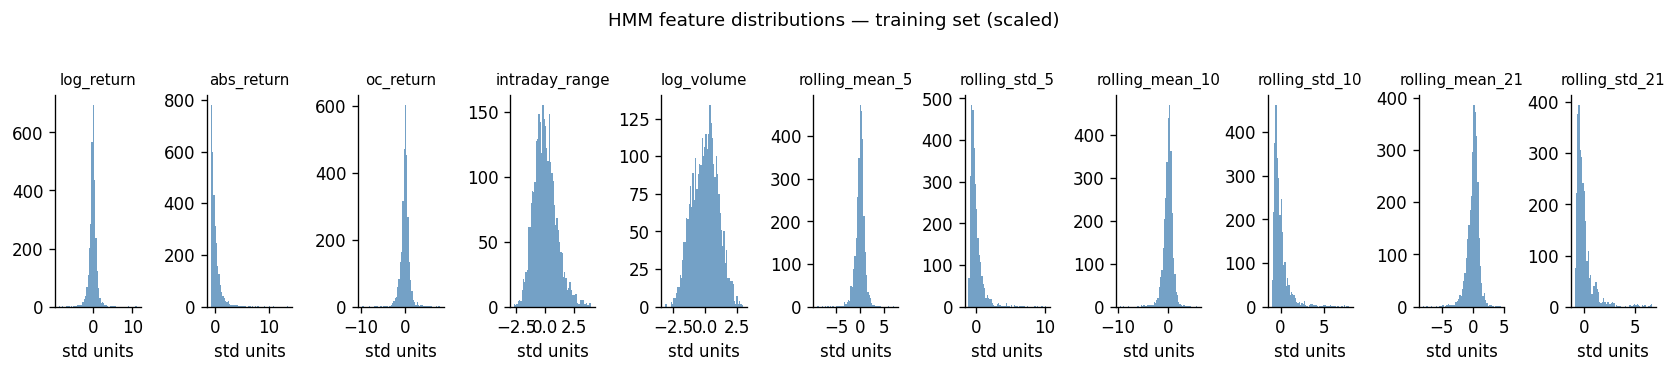

In [5]:
fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat, col in zip(axes, HMM_FEATURES, train_X.T):
    ax.hist(col, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("std units")
fig.suptitle("HMM feature distributions — training set (scaled)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Phase 2a — Model comparison: GaussianHMM vs GMMHMM

We sweep `n_mix ∈ {1, 2, 3}` where:

- `n_mix = 1` → standard `GaussianHMM` (single Gaussian emission per state)
- `n_mix = 2, 3` → `GMMHMM` (Gaussian mixture emissions — more flexible tails)

Selection criterion: **validation BIC** (lower = better).  
BIC = −2 · log P(O | model) + k · log(n) penalises extra parameters.  
Each model is trained with multiple random restarts; the best-scoring restart is kept.

### Two-layer defence against degenerate solutions

EM (Baum-Welch) can converge to degenerate local optima where both hidden states
switch every 1–2 days instead of representing sustained calm / volatile regimes.
A degenerate model can even achieve a *higher* training log-likelihood than the
economically sensible solution, so simply picking the highest-LL restart fails.

We apply two complementary fixes:

#### 1. Volatility-quantile initialisation (restart 0)

hmmlearn's default k-means init clusters in **feature space**. With 11 correlated
rolling statistics, k-means groups observations by their absolute level (e.g. all
high-volume days) regardless of economic regime — producing transition matrices
that are already degenerate before EM even begins.

**Restart 0** instead seeds the model from *volatility quantiles*:
1. Rank each day by `abs_return` (feature index 1 in `HMM_FEATURES`)
2. Assign the bottom 70 % of days to the "calm" state, top 30 % to "volatile"
3. Compute empirical means, covariances, and a transition matrix from these labels
4. Feed these as the starting parameters (`init_params=""`) so EM refines from
   an already economically meaningful starting point

Restarts 1 … n_restarts−1 use hmmlearn's default random k-means init as usual.

#### 2. Penalised restart selection (Nystrup et al., 2015–2019)

Among all restarts, the winner is chosen by **penalised log-likelihood** rather
than raw log-likelihood:

```
penalised_LL = log P(O | model) − λ · Σ_s (1 − p_stay_s)
```

where `1 / (1 − p_stay_s) = avg_duration_s`. A degenerate model (avg dur ≈ 2 days)
has Σ(1 − p_stay) ≈ 1.0; a healthy model (avg dur ≈ 20–200 days) has ≈ 0.01–0.10.
With `λ = HMM_DURATION_PENALTY ≈ n_train`, degenerate restarts are penalised even
if they happen to have slightly higher raw LL.


In [6]:
from src.hmm_model import compare_models

summary_df, comparisons = compare_models(
    train_X=train_X,
    val_X=val_X,
    n_states=HMM_N_STATES,
    n_mix_values=HMM_N_MIX,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)

print("\nModel comparison (sorted by val_BIC — lower is better):")
display(summary_df.reset_index(drop=True))

16:41:30 | INFO    | src.hmm_model | GaussianHMM(n_states=2) best penalised score: -23703.2440
16:41:30 | INFO    | src.hmm_model | GaussianHMM(states=2) — val LL=-6797.70, val BIC=14680.85, val AIC=13909.39, k=157
16:41:31 | WARNING | hmmlearn.base | Model is not converging.  Current: 22514.27614178421 is not greater than 22768.263468271067. Delta is -253.98732648685836
16:41:31 | WARNING | hmmlearn.base | Model is not converging.  Current: -4447.199395810324 is not greater than 7976.289243713118. Delta is -12423.488639523443
16:41:31 | WARNING | hmmlearn.base | Model is not converging.  Current: -4411.357744450627 is not greater than 5260.636746250125. Delta is -9671.994490700752
16:41:31 | WARNING | hmmlearn.base | Model is not converging.  Current: -3426.3606425681382 is not greater than 22128.007169630182. Delta is -25554.36781219832
16:41:31 | WARNING | hmmlearn.base | Model is not converging.  Current: 11599.869210875964 is not greater than 13420.580412305879. Delta is -1820.711


Model comparison (sorted by val_BIC — lower is better):


,model,n_params (k),train_LL,val_LL,train_BIC,val_BIC,train_AIC,val_AIC
0,"GMMHMM(states=2, mix=2)",313,22524.89,9299.43,-42543.79,-16434.87,-44423.78,-17972.87
1,"GMMHMM(states=2, mix=3)",469,21265.02,8347.24,-38775.06,-13451.94,-41592.04,-15756.48
2,GaussianHMM(states=2),157,-23571.34,-6797.70,48399.69,14680.85,47456.69,13909.39


## 4. Visualise model comparison metrics


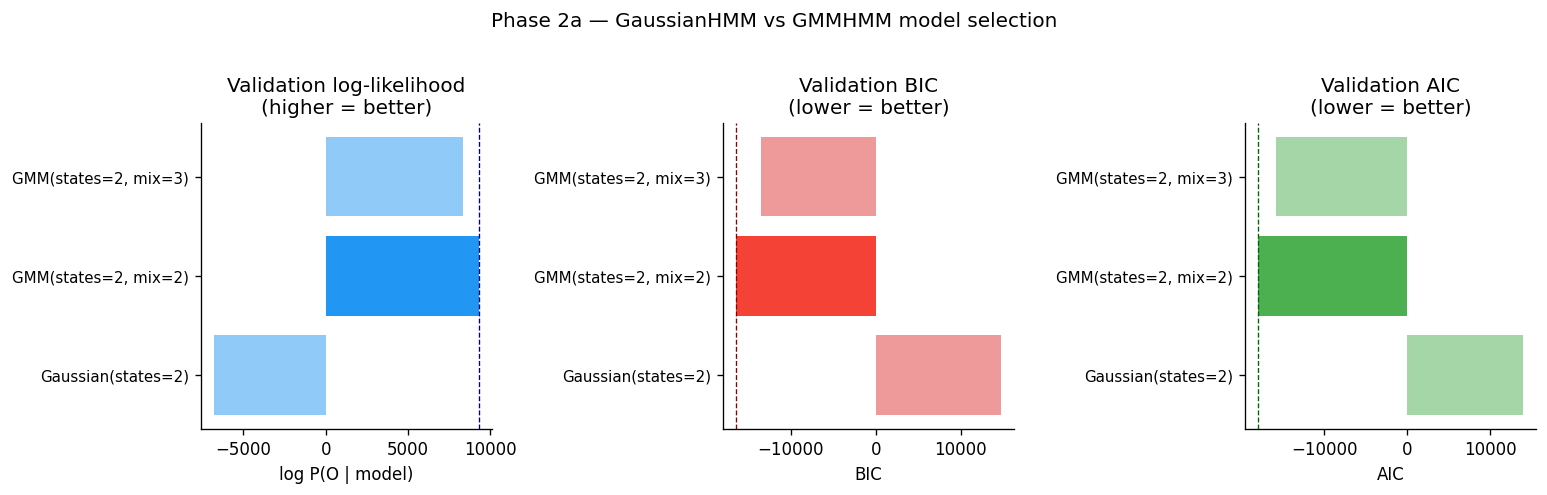

In [7]:
models_short = [
    c.label.replace("GaussianHMM", "Gaussian").replace("GMMHMM", "GMM")
    for c in comparisons
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1 — validation log-likelihood (higher = better)
val_lls = [c.val_log_likelihood for c in comparisons]
colors = ["#2196F3" if ll == max(val_lls) else "#90CAF9" for ll in val_lls]
axes[0].barh(models_short, val_lls, color=colors)
axes[0].set_xlabel("log P(O | model)")
axes[0].set_title("Validation log-likelihood\n(higher = better)")
axes[0].axvline(max(val_lls), color="navy", linewidth=0.8, linestyle="--")

# Panel 2 — validation BIC (lower = better)
val_bics = [c.bic_val for c in comparisons]
colors = ["#F44336" if b == min(val_bics) else "#EF9A9A" for b in val_bics]
axes[1].barh(models_short, val_bics, color=colors)
axes[1].set_xlabel("BIC")
axes[1].set_title("Validation BIC\n(lower = better)")
axes[1].axvline(min(val_bics), color="darkred", linewidth=0.8, linestyle="--")

# Panel 3 — validation AIC (lower = better)
val_aics = [c.aic_val for c in comparisons]
colors = ["#4CAF50" if a == min(val_aics) else "#A5D6A7" for a in val_aics]
axes[2].barh(models_short, val_aics, color=colors)
axes[2].set_xlabel("AIC")
axes[2].set_title("Validation AIC\n(lower = better)")
axes[2].axvline(min(val_aics), color="darkgreen", linewidth=0.8, linestyle="--")

for ax in axes:
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Phase 2a — GaussianHMM vs GMMHMM model selection", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Train vs validation LL — overfitting check

A large gap between training and validation log-likelihood signals overfitting to the training regime.


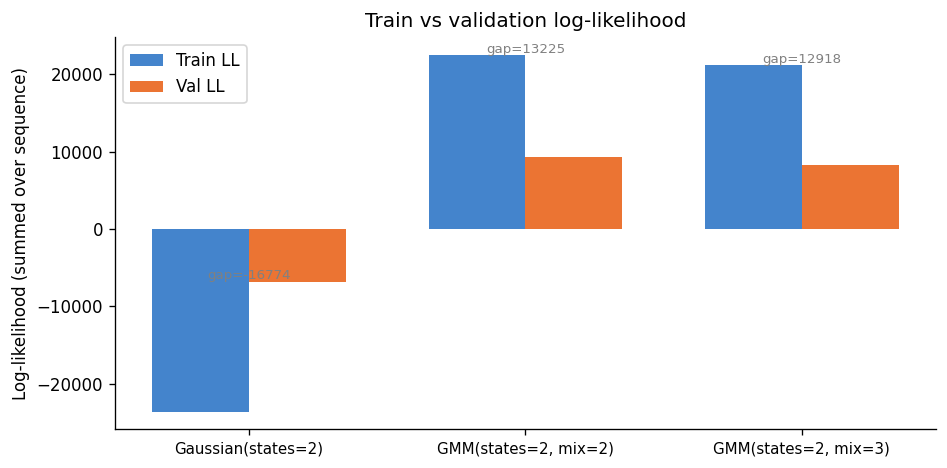

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(comparisons))
width = 0.35

train_lls = [c.train_log_likelihood for c in comparisons]
val_lls = [c.val_log_likelihood for c in comparisons]

ax.bar(x - width / 2, train_lls, width, label="Train LL", color="#1565C0", alpha=0.8)
ax.bar(x + width / 2, val_lls, width, label="Val LL", color="#E65100", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(models_short, fontsize=9)
ax.set_ylabel("Log-likelihood (summed over sequence)")
ax.set_title("Train vs validation log-likelihood")
ax.legend()

for xi, tr, va in zip(x, train_lls, val_lls):
    gap = tr - va
    ax.text(
        xi,
        max(tr, va) + abs(gap) * 0.02,
        f"gap={gap:.0f}",
        ha="center",
        fontsize=8,
        color="grey",
    )

plt.tight_layout()
plt.show()

## 6. Parameter count vs fit trade-off


In [9]:
param_df = pd.DataFrame(
    [
        {
            "model": c.label,
            "n_params (k)": c.n_params,
            "val_LL": round(c.val_log_likelihood, 2),
            "val_BIC": round(c.bic_val, 2),
            "val_AIC": round(c.aic_val, 2),
            "LL/param": round(c.val_log_likelihood / c.n_params, 4),
        }
        for c in comparisons
    ]
).sort_values("val_BIC")

display(param_df.reset_index(drop=True))

,model,n_params (k),val_LL,val_BIC,val_AIC,LL/param
0,"GMMHMM(states=2, mix=2)",313,9299.43,-16434.87,-17972.87,29.7106
1,"GMMHMM(states=2, mix=3)",469,8347.24,-13451.94,-15756.48,17.7980
2,GaussianHMM(states=2),157,-6797.70,14680.85,13909.39,-43.2974


## 7. Identify the winner and inspect its parameters


In [10]:
best_label = summary_df.iloc[0]["model"]
best_comp = next(c for c in comparisons if c.label == best_label)
best_model = best_comp.model

print(f"Winner: {best_label}")
print(f"  val log-likelihood : {best_comp.val_log_likelihood:.2f}")
print(f"  val BIC            : {best_comp.bic_val:.2f}")
print(f"  val AIC            : {best_comp.aic_val:.2f}")
print(f"  n_params (k)       : {best_comp.n_params}")

Winner: GMMHMM(states=2, mix=2)
  val log-likelihood : 9299.43
  val BIC            : -16434.87
  val AIC            : -17972.87
  n_params (k)       : 313


In [11]:
# Transition matrix
print("Transition matrix (A):")
trans_df = pd.DataFrame(
    best_model.transmat_,
    index=[f"from_state_{i}" for i in range(HMM_N_STATES)],
    columns=[f"to_state_{j}" for j in range(HMM_N_STATES)],
).round(4)
display(trans_df)

print("\nStarting probabilities (pi):")
print(
    pd.Series(best_model.startprob_, index=[f"state_{i}" for i in range(HMM_N_STATES)])
    .round(4)
    .to_string()
)

Transition matrix (A):


,to_state_0,to_state_1
from_state_0,0.9940,0.0060
from_state_1,0.0845,0.9155



Starting probabilities (pi):
state_0    1.0
state_1    0.0


In [12]:
# State means (in scaled feature space)
print("State means (scaled feature space):")
if hasattr(best_model, "means_") and best_model.means_.ndim == 2:
    # GaussianHMM
    means_df = pd.DataFrame(
        best_model.means_,
        index=[f"state_{i}" for i in range(HMM_N_STATES)],
        columns=HMM_FEATURES,
    ).round(4)
    display(means_df)
else:
    # GMMHMM — show per-mixture-component means for each state
    for s in range(HMM_N_STATES):
        print(f"\nState {s} mixture means:")
        mix_df = pd.DataFrame(
            best_model.means_[s],
            index=[f"mix_{m}" for m in range(best_model.n_mix)],
            columns=HMM_FEATURES,
        ).round(4)
        display(mix_df)

State means (scaled feature space):

State 0 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
mix_0,0.4920,-0.162,0.4198,-0.2674,-0.2119,0.2836,-0.2037,0.2255,-0.2156,0.2102,-0.2168
mix_1,-0.5984,-0.082,-0.5260,0.0225,0.0079,-0.2545,-0.1510,-0.1330,-0.1727,-0.0443,-0.1814



State 1 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
mix_0,0.3059,0.2003,0.1695,1.2421,1.3243,-0.4225,1.6096,-0.5135,1.7590,-0.3256,1.6575
mix_1,-0.1040,2.4377,0.0889,2.2170,1.7050,-0.6314,2.9370,-1.0568,3.2018,-1.7713,3.3361


In [13]:
# Identify which state is volatile and which is calm
from src.hmm_model import viterbi_decode, identify_volatile_state

train_states = viterbi_decode(best_model, train_X)
abs_return_idx = HMM_FEATURES.index("abs_return")
state_map = identify_volatile_state(
    best_model, train_X, train_states, feature_idx=abs_return_idx
)

volatile_state = state_map["volatile"]
calm_state = state_map["calm"]

print(f"State map: {state_map}")

n_volatile = (train_states == volatile_state).sum()
n_calm = (train_states == calm_state).sum()
print(f"\nTraining regime distribution:")
print(
    f"  Calm     (state {calm_state}): {n_calm:,} days  ({100*n_calm/len(train_states):.1f}%)"
)
print(
    f"  Volatile (state {volatile_state}): {n_volatile:,} days  ({100*n_volatile/len(train_states):.1f}%)"
)

16:41:44 | INFO    | src.hmm_model | State identification — volatile=1 (mean abs_return=1.98342), calm=0 (mean abs_return=-0.11248)


State map: {'volatile': 1, 'calm': 0}

Training regime distribution:
  Calm     (state 0): 2,839 days  (94.6%)
  Volatile (state 1): 161 days  (5.4%)


## 8. State feature distributions (original scale)


In [14]:
# Per-state feature means on the training set (original, unscaled values)
state_stats = []
for s, label in [(calm_state, "calm"), (volatile_state, "volatile")]:
    mask = train_states == s
    row = {"regime": label, "n_days": int(mask.sum())}
    for feat, col in zip(HMM_FEATURES, train_raw.T):
        row[feat] = col[mask].mean()
    state_stats.append(row)

state_df = pd.DataFrame(state_stats).set_index("regime")
print("Per-regime feature means (original scale):")
display(state_df.round(6))

Per-regime feature means (original scale):


,n_days,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
regime,,,,,,,,,,,,
calm,2839,0.000351,0.006755,-0.000018,-4.621510,18.554436,0.000468,0.008252,0.000468,0.008563,0.000470,0.008746
volatile,161,-0.001084,0.026475,0.000482,-3.311973,19.715989,-0.003073,0.032309,-0.003141,0.032948,-0.003137,0.032650


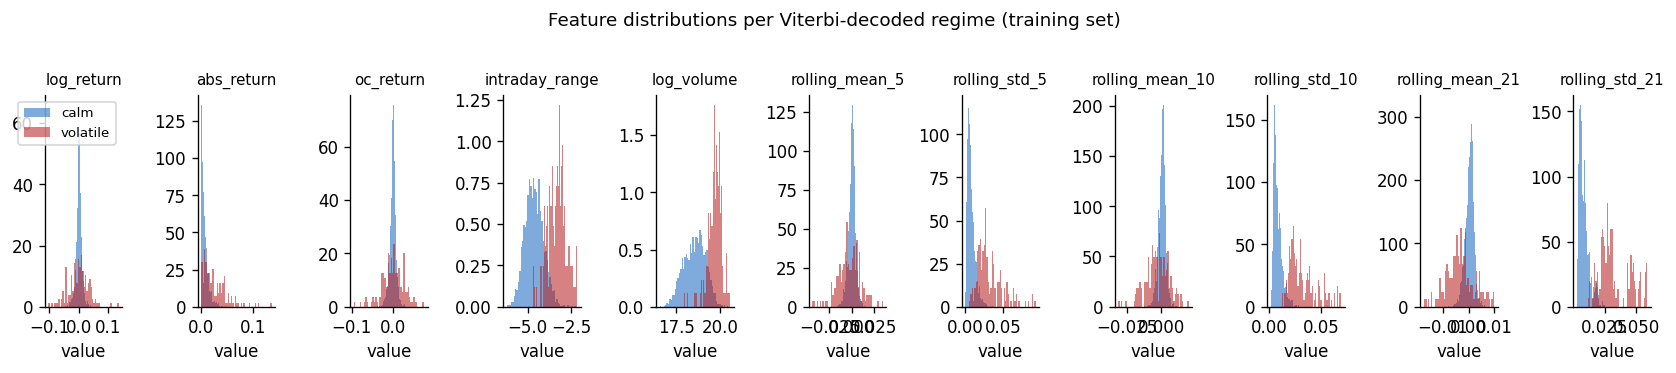

In [15]:
palette = {"calm": "#1565C0", "volatile": "#B71C1C"}

fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat in zip(axes, HMM_FEATURES):
    for s, label in [(calm_state, "calm"), (volatile_state, "volatile")]:
        mask = train_states == s
        ax.hist(
            train_raw[mask, HMM_FEATURES.index(feat)],
            bins=50,
            alpha=0.55,
            label=label,
            color=palette[label],
            density=True,
            edgecolor="none",
        )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("value")
    if feat == HMM_FEATURES[0]:
        ax.legend(fontsize=8)

fig.suptitle(
    "Feature distributions per Viterbi-decoded regime (training set)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 9. Transition matrix heatmap


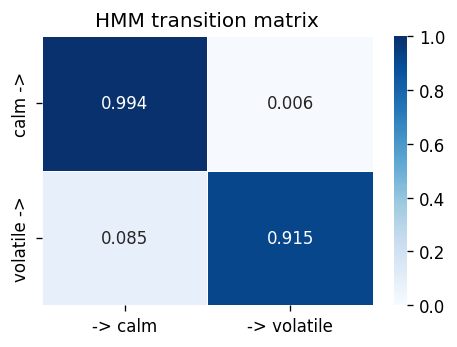

Average calm duration: 167.5 trading days  (8.0 months)
Average volatile duration: 11.8 trading days  (0.6 months)


In [16]:
fig, ax = plt.subplots(figsize=(4, 3))

state_labels = ["calm", "volatile"] if calm_state == 0 else ["volatile", "calm"]
sns.heatmap(
    best_model.transmat_,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f"-> {l}" for l in state_labels],
    yticklabels=[f"{l} ->" for l in state_labels],
    ax=ax,
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
ax.set_title("HMM transition matrix")
plt.tight_layout()
plt.show()

# Implied average regime duration
for s, name in [(calm_state, "calm"), (volatile_state, "volatile")]:
    stay_prob = best_model.transmat_[s, s]
    avg_dur = 1 / (1 - stay_prob) if stay_prob < 1.0 else float("inf")
    print(
        f"Average {name} duration: {avg_dur:.1f} trading days  ({avg_dur/21:.1f} months)"
    )

## 10. Save the winning model and scaler


In [17]:
from src.hmm_model import save_model

MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "hmm_winner.joblib"
scaler_path = MODELS_DIR / "hmm_scaler.joblib"
meta_path = MODELS_DIR / "hmm_meta.joblib"

save_model(best_model, str(model_path))
joblib.dump(scaler, str(scaler_path))

meta = {
    "winning_label": best_label,
    "n_states": HMM_N_STATES,
    "hmm_features": HMM_FEATURES,
    "volatile_state": volatile_state,
    "calm_state": calm_state,
    "val_log_likelihood": best_comp.val_log_likelihood,
    "val_bic": best_comp.bic_val,
    "val_aic": best_comp.aic_val,
    "n_params": best_comp.n_params,
}
joblib.dump(meta, str(meta_path))

print("Saved:")
print(f"  model  -> {model_path}")
print(f"  scaler -> {scaler_path}")
print(f"  meta   -> {meta_path}")

16:41:44 | INFO    | src.hmm_model | Saved model → /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_winner.joblib


Saved:
  model  -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_winner.joblib
  scaler -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_scaler.joblib
  meta   -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_meta.joblib


## 11. Summary

| Item                        | Value                                                                                                                  |
| --------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| HMM features (11)           | `log_return`, `abs_return`, `oc_return`, `intraday_range`, `log_volume`, `rolling_mean_5/10/21`, `rolling_std_5/10/21` |
| Models trained              | GaussianHMM, GMMHMM(mix=2), GMMHMM(mix=3)                                                                              |
| Selection criterion         | Validation BIC (lower = better)                                                                                        |
| Winner                      | GMMHMM                                                                                                                 |
| Volatile / calm state index | _see cell 7 output_                                                                                                    |
| Model saved                 | `models/hmm_winner.joblib`                                                                                             |
| Scaler saved                | `models/hmm_scaler.joblib`                                                                                             |
| Metadata saved              | `models/hmm_meta.joblib`                                                                                               |

**Next steps (not in this notebook):**

- **2b**: Higher-order Markov test — augmented 4-state HMM vs 2-state first-order
- **2c**: Viterbi regime overlay on SPY price — sanity check vs 2008 GFC, 2020 COVID, 2022 rate hikes
